# Predicción de fuga de clientes (churn) en una empresa de telecomunicaciones

**Proyecto Integrador – Fase 1**
Modelos y Simulación de Sistemas I – 2026 II

Integrantes:

Zareth Mariana Vega Sánchez

Jonathan Alfonso Pérez

## 1. Introducción

**Problema seleccionado.**
Una empresa de servicios de telecomunicaciones
necesita anticipar qué clientes cancelarán su servicio. Actualmente la
cancelación solo se conoce cuando ya ocurrió, lo que impide cualquier acción de retención. El problema consiste en estimar ese riesgo de forma anticipada a partir de la información disponible del cliente.

**Objetivo del modelo.**
Estimar, para cada cliente, la probabilidad de que
cancele el servicio, usando su perfil demográfico, los servicios que tiene contratados y sus condiciones de contrato y facturación. La salida del modelo permite priorizar el contacto comercial hacia los clientes con mayor riesgo, en lugar de aplicar campañas de retención indiscriminadas.

**Tipo de problema.** Aprendizaje supervisado, clasificación binaria. Las
clases están desbalanceadas (aproximadamente 73,5 % / 26,5 %), lo que
condiciona la elección de la métrica de evaluación.

**Variable objetivo.** `Churn`, de tipo categórico binario, con valores
`Yes` (el cliente canceló el servicio durante el último mes) y `No` (el
cliente permanece activo).

**Fuente de los datos.** Conjunto *Telco Customer Churn*, publicado por IBM dentro de sus conjuntos de datos de muestra y difundido a través de Kaggle. Su propósito declarado es predecir el comportamiento del cliente para diseñar programas focalizados de retención, que coincide con el objetivo
planteado en este proyecto. Contiene 7.043 registros y 21 columnas; cada fila corresponde a un cliente. Es un corte transversal: no contiene variable de fecha ni estructura secuencial, por lo que no constituye una serie de tiempo.

## 2. Descripción del conjunto de datos

**Observaciones.** 7.043 registros. Cada fila corresponde a un cliente
único, identificado por `customerID`. No hay registros repetidos por
cliente, de modo que no existen grupos naturales que obliguen a una
partición agrupada.

**Variables.** 21 columnas: 1 identificador (`customerID`), 19 variables
predictoras y 1 variable objetivo (`Churn`).

**Significado de la variable objetivo.** `Churn` indica si el cliente se
fue durante el último mes (`Yes`) o continúa activo (`No`). Es la clase
que el modelo debe anticipar antes de que la cancelación ocurra.

### 2.1 Tipos de variables

| Tipo | Cantidad | Variables |
|---|---|---|
| Numéricas continuas | 3 | `tenure`, `MonthlyCharges`, `TotalCharges` |
| Categóricas binarias | 6 | `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling` |
| Categóricas nominales (3+ niveles) | 10 | `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaymentMethod` |
| Identificador | 1 | `customerID` |
| Objetivo | 1 | `Churn` |

`SeniorCitizen` es la única variable categórica que viene ya codificada
como entero (0/1); las demás son texto. `TotalCharges` viene almacenada
como texto y requiere conversión a numérica.

### 2.2 Agrupación temática de las predictoras

La documentación del conjunto organiza los atributos en tres bloques:
información demográfica, servicios contratados e información de la
cuenta. Aquí se conserva esa estructura, subdividiendo el bloque de
servicios en telefonía e internet, porque `MultipleLines` y las siete
variables de internet incorporan un nivel adicional ("No phone service" /
"No internet service") cuyo tratamiento en la codificación será común
dentro de cada subgrupo.

| Bloque | Variables |
|---|---|
| Información demográfica | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| Servicios – telefonía | `PhoneService`, `MultipleLines` |
| Servicios – internet | `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| Información de la cuenta | `tenure`, `Contract`, `PaymentMethod`, `PaperlessBilling`, `MonthlyCharges`, `TotalCharges` |

### 2.3 Limitaciones del conjunto de datos

1. **Ausencia de variables de comportamiento.** El conjunto describe el
   estado contractual del cliente, pero no incorpora señales de uso
   (consumo de datos, minutos, incidencias técnicas), historial de pagos
   ni contactos con el servicio al cliente. En problemas de churn reales
   estas suelen ser las variables más informativas, por lo que el techo
   de desempeño alcanzable aquí está limitado por el diseño del
   conjunto.

2. **Corte transversal sin dimensión temporal.** No se registra la fecha
   de alta ni la de cancelación. `tenure` mide la antigüedad al momento
   del corte, pero no permite reconstruir la secuencia de eventos ni
   plantear el problema como análisis de supervivencia (tiempo hasta el
   evento), que sería la formulación más natural.
3. **Definición de la cancelación.** La documentación define `Churn =
   Yes` como los clientes que se fueron durante el último mes, sin
   distinguir entre baja voluntaria y baja involuntaria (por ejemplo,
   por impago). Ambas quedan agrupadas bajo la misma clase, aunque
   exigen intervenciones comerciales distintas y probablemente tengan
   determinantes diferentes.

4. **Ausencia de diccionario de datos formal.** La documentación
   disponible describe los atributos en prosa, agrupados por tema, pero
   no publica definiciones operativas por columna. En consecuencia,
   algunos criterios quedan sin documentar: por ejemplo, el umbral de
   edad que define `SeniorCitizen = 1` se asume en 65 años por
   convención, sin respaldo explícito en la fuente.

5. **Valores faltantes.** `TotalCharges` presenta 11 ausencias (0,156 %),
   concentradas en clientes con `tenure = 0`, por ende se debe hacer algun tratamiento.

## 3. Exploración de los datos

El objetivo de esta sección es describir el conjunto y detectar problemas
que condicionen la preparación posterior.

> Este análisis es exclusivamente
> descriptivo. No se ajusta aquí ningún transformador ni se calcula
> ningún parámetro que vaya a aplicarse sobre los datos. Las estadísticas
> mostradas sirven para tomar decisiones de diseño (qué imputar, qué
> codificar, qué conservar).

### 3.1 Cargar Data set

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, joblib

# Semilla
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)

pandas: 3.0.3
numpy: 2.4.6
scikit-learn: 1.9.0
joblib: 1.5.3


In [5]:
URL = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
       "master/data/Telco-Customer-Churn.csv")
df = pd.read_csv(URL)

print("Datos cargados:", df.shape)
df.head()

Datos cargados: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.2 Dimensiones y tipos de variables

In [6]:
print("Dimensiones:", df.shape)
print(f"Observaciones: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print("\nRegistros duplicados:", df.duplicated().sum())
print("customerID únicos:", df["customerID"].nunique(), "de", len(df))

print("\n--- Tipos de datos ---")
df.info()

Dimensiones: (7043, 21)
Observaciones: 7,043 | Columnas: 21

Registros duplicados: 0
customerID únicos: 7043 de 7043

--- Tipos de datos ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  Stream

In [7]:
# Número de niveles de cada variable no numérica
cat_cols = df.select_dtypes(include="object").columns.drop(["customerID", "Churn"])
niveles = pd.DataFrame({
    "n_niveles": df[cat_cols].nunique(),
    "valores": [", ".join(map(str, df[c].unique())) for c in cat_cols]
}).sort_values("n_niveles")
display(niveles)

C:\Users\vgzar\AppData\Local\Temp\ipykernel_18864\2403464461.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.drop(["customerID", "Churn"])


,n_niveles,valores
gender,2,"Female, Male"
Partner,2,"Yes, No"
Dependents,2,"No, Yes"
PhoneService,2,"No, Yes"
PaperlessBilling,2,"Yes, No"
MultipleLines,3,"No phone service, No, Yes"
OnlineSecurity,3,"No, Yes, No internet service"
InternetService,3,"DSL, Fiber optic, No"
OnlineBackup,3,"Yes, No, No internet service"
DeviceProtection,3,"No, Yes, No internet service"


No hay registros duplicados y `customerID` es único en las 7.043 filas,
lo que confirma que cada observación es un cliente distinto y que la
partición aleatoria estándar no genera fuga por repetición de individuos.

Ninguna variable categórica supera los cuatro niveles (`PaymentMethod` es la de mayor cardinalidad). Esto tiene una consecuencia práctica: la codificación *one-hot* es viable sin riesgo de explosión dimensional.

Se confirma también que `TotalCharges` figura como texto pese a ser una magnitud continua, anomalía que se examina a continuación.

### 3.3 Valores faltantes

In [8]:
# La lectura directa no detecta ausencias: están codificadas como cadenas vacías
print("Nulos detectados por pandas antes de convertir:", df.isna().sum().sum())

blancos = (df["TotalCharges"].astype(str).str.strip() == "").sum()
print(f"Celdas en blanco en TotalCharges: {blancos} ({blancos/len(df)*100:.3f} %)")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

faltantes = pd.DataFrame({
    "n_faltantes": df.isna().sum(),
    "pct": (df.isna().mean() * 100).round(3)
})
display(faltantes[faltantes["n_faltantes"] > 0])

Nulos detectados por pandas antes de convertir: 0
Celdas en blanco en TotalCharges: 11 (0.156 %)


,n_faltantes,pct
TotalCharges,11,0.156


In [9]:
# Caracterización de los registros con ausencia
sin_total = df[df["TotalCharges"].isna()]
display(sin_total[["customerID", "tenure", "Contract",
                   "MonthlyCharges", "TotalCharges", "Churn"]])

print("Valores únicos de tenure en esos registros:", sin_total["tenure"].unique())
print("Valores únicos de Churn en esos registros:", sin_total["Churn"].unique())
print("Clientes con tenure = 0 en todo el conjunto:", (df["tenure"] == 0).sum())

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,Two year,52.55,NaN,No
753,3115-CZMZD,0,Two year,20.25,NaN,No
936,5709-LVOEQ,0,Two year,80.85,NaN,No
1082,4367-NUYAO,0,Two year,25.75,NaN,No
1340,1371-DWPAZ,0,Two year,56.05,NaN,No
3331,7644-OMVMY,0,Two year,19.85,NaN,No
3826,3213-VVOLG,0,Two year,25.35,NaN,No
4380,2520-SGTTA,0,Two year,20.00,NaN,No
5218,2923-ARZLG,0,One year,19.70,NaN,No
6670,4075-WKNIU,0,Two year,73.35,NaN,No


Valores únicos de tenure en esos registros: [0]
Valores únicos de Churn en esos registros: <StringArray>
['No']
Length: 1, dtype: str
Clientes con tenure = 0 en todo el conjunto: 11


La lectura directa no detecta ausencias: las celdas vacías de
`TotalCharges` están almacenadas como cadenas con un espacio, y solo
aparecen como `NaN` tras forzar la conversión a numérica. Un `isna()`
aplicado sin inspección previa habría concluido que el conjunto está
completo.

Cuantificadas: 11 ausencias (0,156 %), todas en `TotalCharges`.

El patrón importa más que la cantidad. Los once registros son
exactamente todos los clientes con `tenure = 0` del conjunto. No es una
ausencia aleatoria: son clientes recién suscritos que aún no han
recibido su primera factura, de modo que su facturación acumulada no es un dato perdido sino uno que todavía no existe. Esto determina la
estrategia de tratamiento.

### 3.4 Estadísticas descriptivas

#### 3.3.1 Variables numéricas

In [10]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
display(df[num_cols].describe().round(2))

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


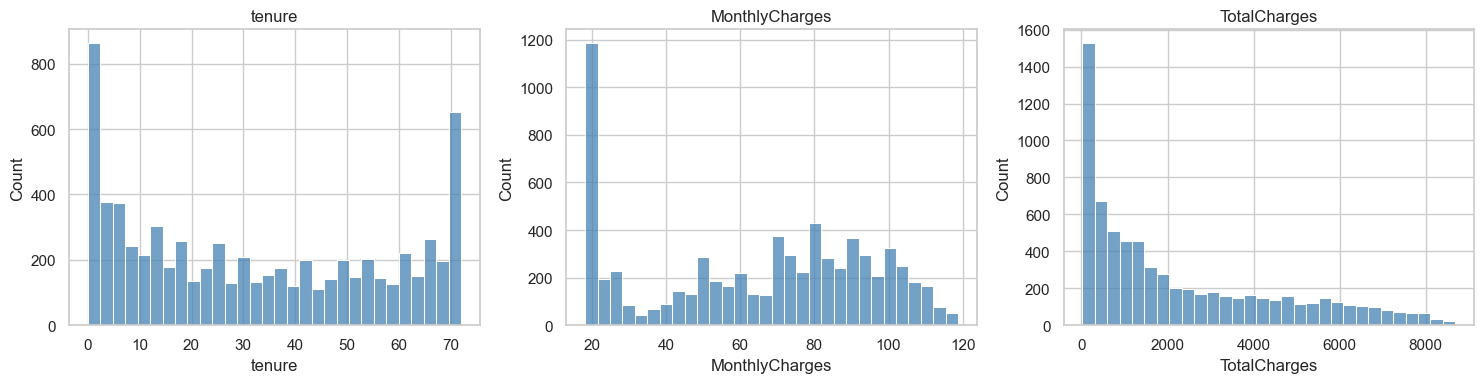

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], bins=30, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Las tres variables operan en escalas muy distintas: `tenure` entre 0 y 72
meses, `MonthlyCharges` entre 18 y 119 dólares, `TotalCharges` entre 19 y
8.685.

No hay valores imposibles ni negativos, y los máximos son coherentes con el dominio: un cliente con 72 meses o con 8.685 dólares acumulados es un cliente antiguo, no un error de registro. No se identifican atípicos que requieran tratamiento.

Las distribuciones no son normales. `tenure` se concentra en los
extremos, `MonthlyCharges` es bimodal, esto refleja la separación entre
clientes con y sin internet y `TotalCharges` presenta fuerte asimetría a
la derecha, como corresponde a un acumulado. La media no es un resumen
representativo en estas variables, lo que desaconseja la imputación por
media.

#### 3.4.2 Variables categóricas

In [12]:
cat_cols = [c for c in df.columns
            if c not in ["customerID", "Churn", "tenure",
                         "MonthlyCharges", "TotalCharges"]]

resumen = pd.DataFrame([{
    "variable": c,
    "n_niveles": df[c].nunique(),
    "moda": df[c].value_counts().index[0],
    "pct_moda": round(df[c].value_counts(normalize=True).iloc[0] * 100, 1),
    "nivel_menor": df[c].value_counts().index[-1],
    "pct_menor": round(df[c].value_counts(normalize=True).iloc[-1] * 100, 1)
} for c in cat_cols]).sort_values("pct_moda", ascending=False)

display(resumen.reset_index(drop=True))

,variable,n_niveles,moda,pct_moda,nivel_menor,pct_menor
0,PhoneService,2,Yes,90.3,No,9.7
1,SeniorCitizen,2,0,83.8,1,16.2
2,Dependents,2,No,70.0,Yes,30.0
3,PaperlessBilling,2,Yes,59.2,No,40.8
4,Contract,3,Month-to-month,55.0,One year,20.9
5,Partner,2,No,51.7,Yes,48.3
6,gender,2,Male,50.5,Female,49.5
7,OnlineSecurity,3,No,49.7,No internet service,21.7
8,TechSupport,3,No,49.3,No internet service,21.7
9,MultipleLines,3,No,48.1,No phone service,9.7


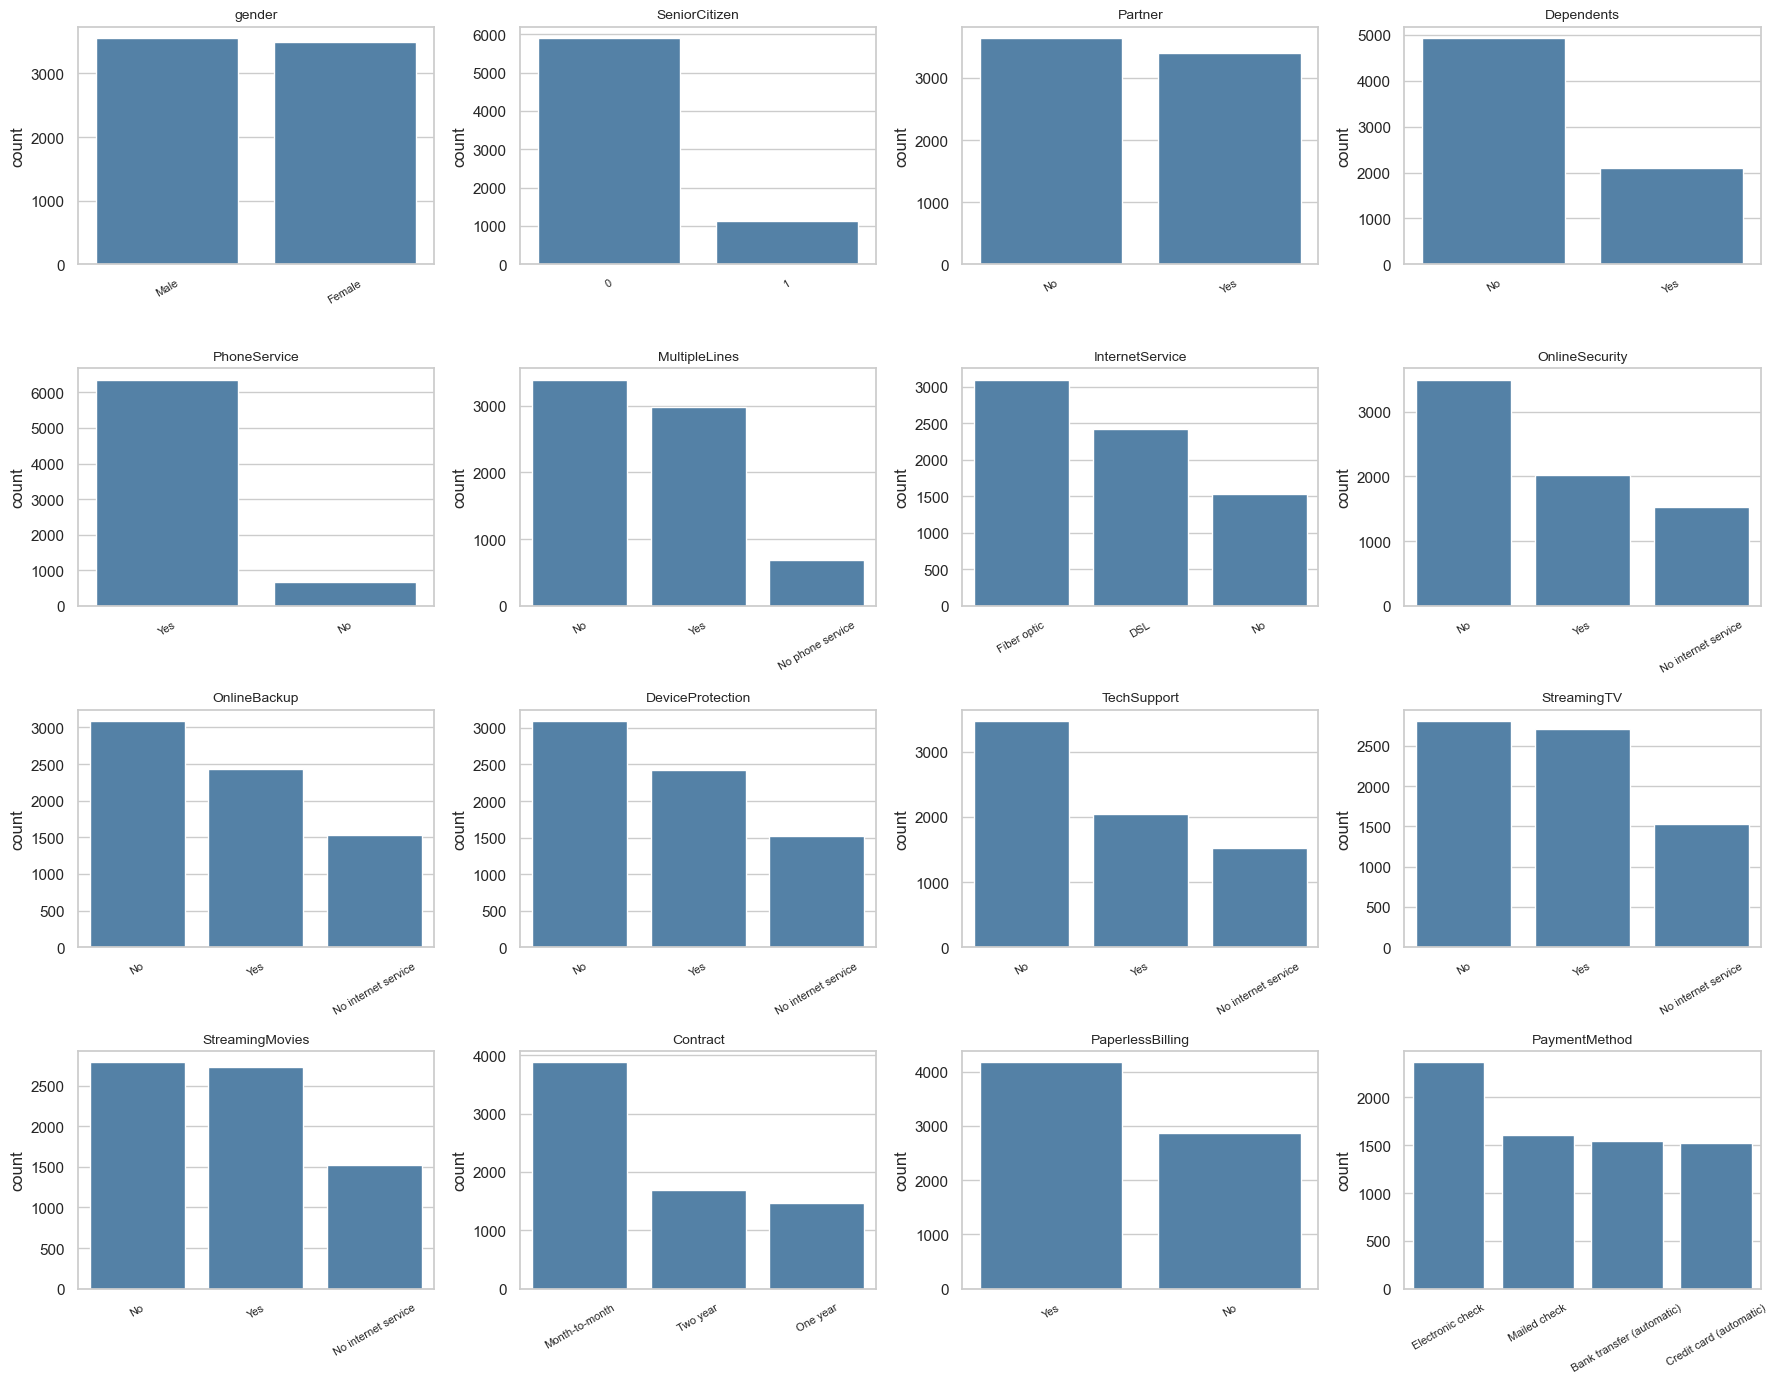

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flatten(), cat_cols):
    orden = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=orden, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
plt.tight_layout()
plt.show()

Las 16 variables categóricas tienen entre dos y cuatro niveles, ninguna
con cardinalidad alta. Tres observaciones relevantes.

`PhoneService` concentra el 90,3 % en un
solo nivel y `SeniorCitizen` el 83,8 %. Su varianza es baja, lo que
reduce su capacidad de discriminar entre clases, asi mismo el nivel "No internet service" aparece en exactamente el 21,7 % de los registros en
siete variables (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`,
`TechSupport`, `StreamingTV`, `StreamingMovies`) y coincide con el 21,7 %
de `InternetService = No`.

Finalmente, La mayoría de clientes tiene contrato mes a
mes (55,0 %), la modalidad de menor compromiso, y el medio de pago más
frecuente es el cheque electrónico (33,6 %).

### 3.5 Distribución de la variable objetivo

In [14]:
conteo = df["Churn"].value_counts()
pct = df["Churn"].value_counts(normalize=True) * 100
display(pd.DataFrame({"registros": conteo, "porcentaje": pct.round(2)}))

razon = conteo["No"] / conteo["Yes"]
print(f"Razón de desbalance (No:Yes) = {razon:.2f} : 1")
print(f"Tasa de cancelación global = {pct['Yes']:.2f} %")

,registros,porcentaje
Churn,,
No,5174,73.46
Yes,1869,26.54


Razón de desbalance (No:Yes) = 2.77 : 1
Tasa de cancelación global = 26.54 %


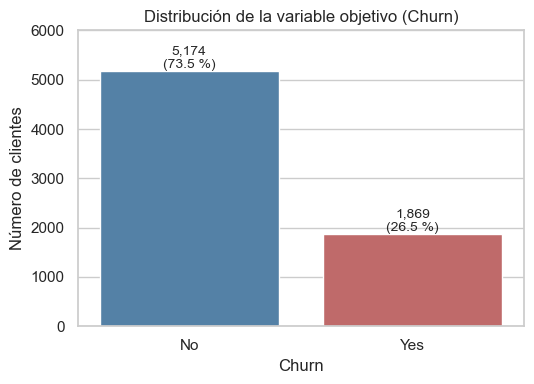

In [15]:
fig, ax = plt.subplots(figsize=(5.5, 4))
sns.countplot(data=df, x="Churn", order=["No", "Yes"], ax=ax,
              hue="Churn", hue_order=["No", "Yes"],
              palette=["steelblue", "indianred"], legend=False)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}\n({p.get_height()/len(df)*100:.1f} %)",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

ax.set_title("Distribución de la variable objetivo (Churn)")
ax.set_ylabel("Número de clientes")
ax.set_ylim(0, 6000)
plt.tight_layout()
plt.show()

La clase positiva (`Yes`) reúne 1.869 registros, el 26,5 % del total,
frente a 5.174 clientes activos (73,5 %). El desbalance es moderado. No justifica técnicas agresivas de
remuestreo.

Teniendo en cuenta este porcentaje de desbalanceo, entonces *accuracy* como métrica principal, no resulta ser la mas significativa, ya que un clasificador que prediga siempre `No` alcanzaría 73,5 % de aciertos sin identificar a
un solo cliente en riesgo. Por ende, La evaluación se centrará por tanto en *recall*, F1 y ROC-AUC sobre la clase positiva.



### 3.6 Relación entre las variables predictoras y la variable objetivo

#### 3.6.1 Variables categóricas

In [16]:
# Tasa de cancelación por nivel de cada variable categórica
tasas = []
for c in cat_cols:
    t = df.groupby(c)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
    tasas.append(pd.DataFrame({
        "variable": c,
        "nivel": t.index.astype(str),
        "pct_churn": t.values.round(1),
        "n": df[c].value_counts().reindex(t.index).values
    }))

tasas = pd.concat(tasas, ignore_index=True)

# Rango de variación: diferencia entre el nivel de mayor y menor cancelación
rango = (tasas.groupby("variable")["pct_churn"]
              .agg(min_pct="min", max_pct="max")
              .assign(rango=lambda d: (d.max_pct - d.min_pct).round(1))
              .sort_values("rango", ascending=False))
display(rango)

,min_pct,max_pct,rango
variable,,,
Contract,2.8,42.7,39.9
InternetService,7.4,41.9,34.5
OnlineSecurity,7.4,41.8,34.4
TechSupport,7.4,41.6,34.2
OnlineBackup,7.4,39.9,32.5
DeviceProtection,7.4,39.1,31.7
PaymentMethod,15.2,45.3,30.1
StreamingMovies,7.4,33.7,26.3
StreamingTV,7.4,33.5,26.1


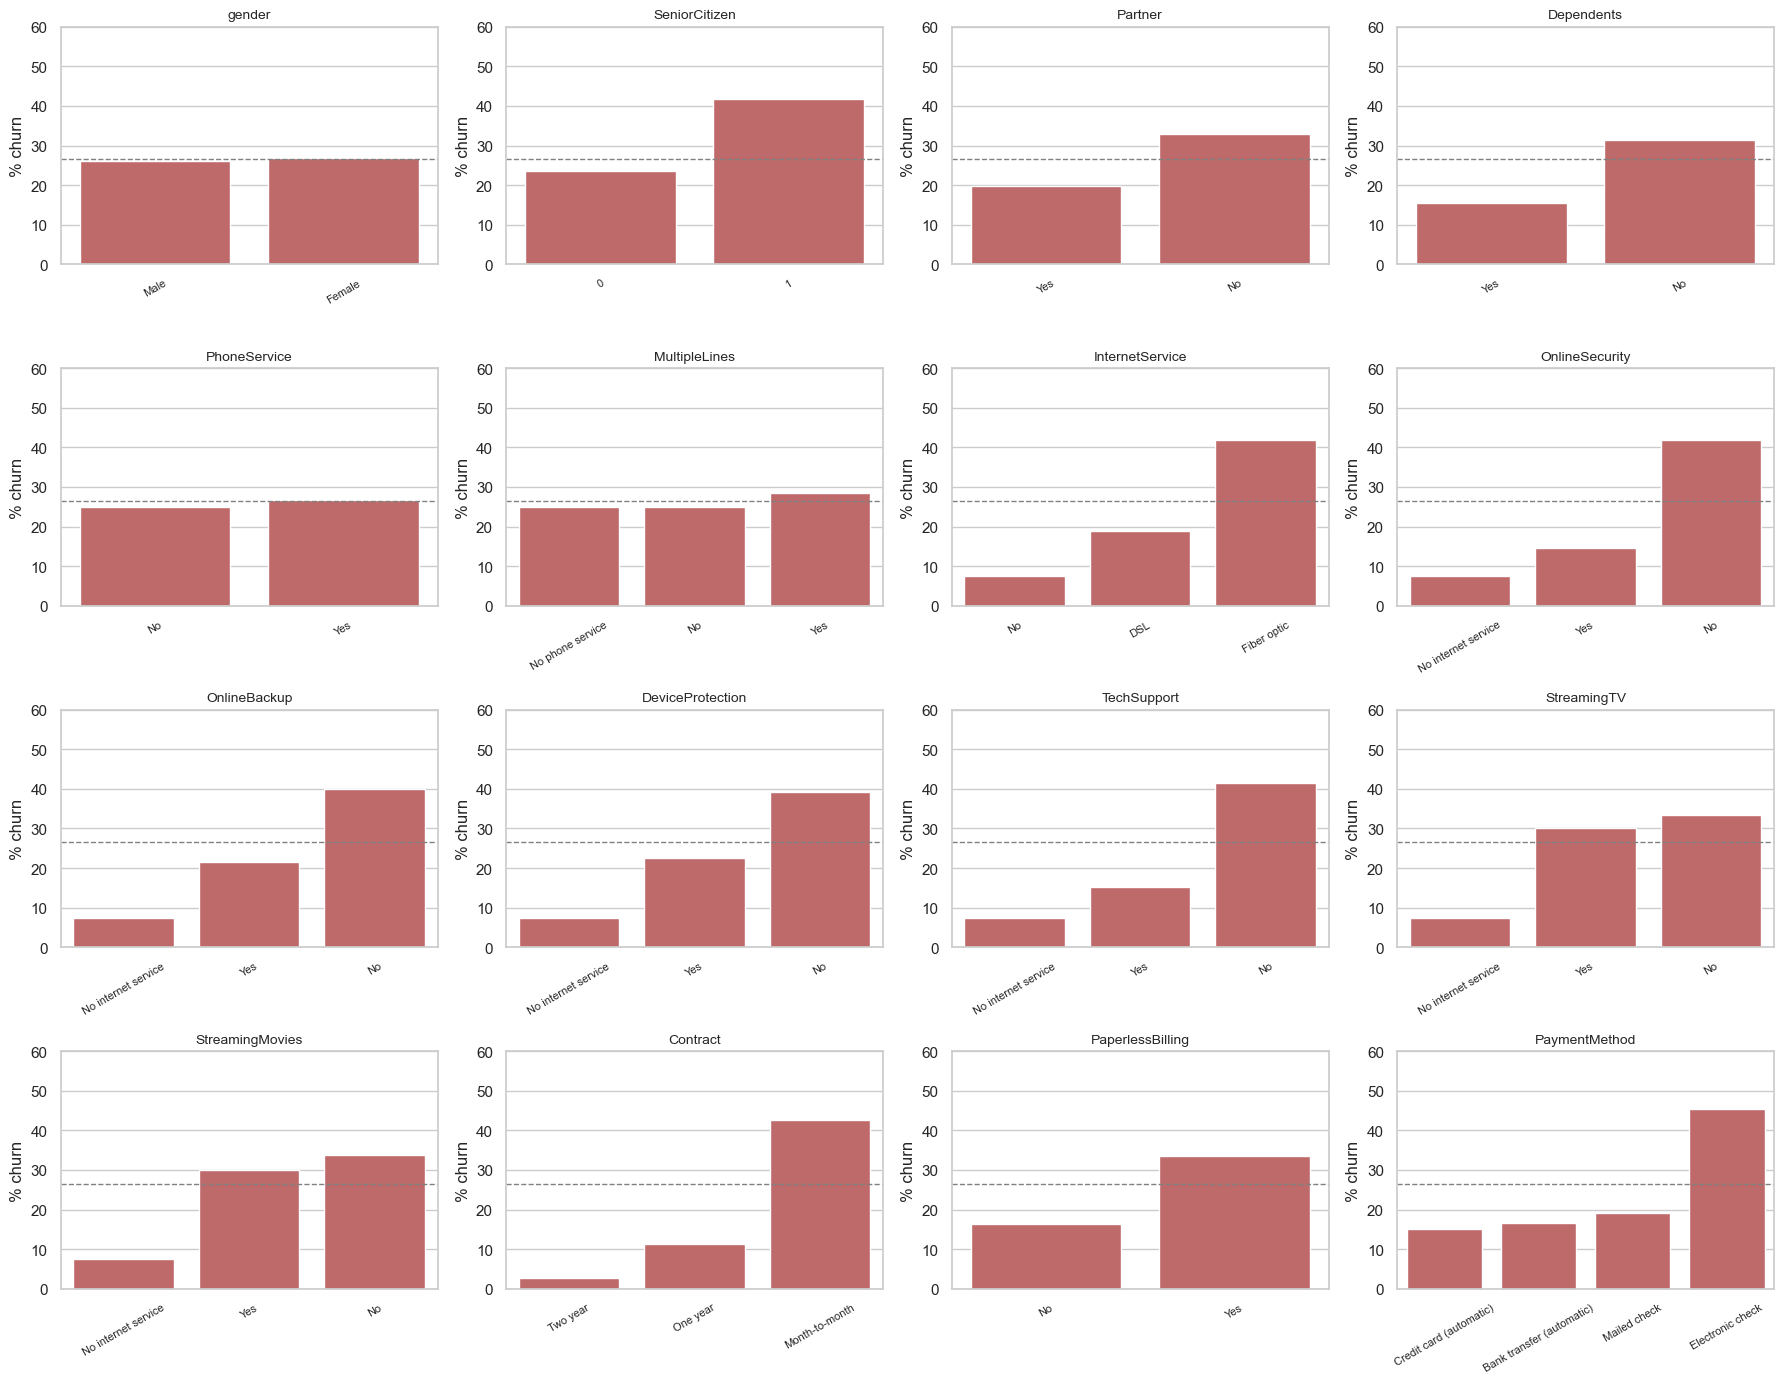

In [17]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flatten(), cat_cols):
    sub = tasas[tasas["variable"] == col].sort_values("pct_churn")
    sns.barplot(data=sub, x="nivel", y="pct_churn", ax=ax, color="indianred")
    ax.axhline(26.5, color="gray", ls="--", lw=1)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("% churn")
    ax.set_ylim(0, 60)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
plt.tight_layout()
plt.show()

La línea discontinua marca la tasa global de cancelación (26,5 %); un
nivel es informativo en la medida en que se aleja de ella. La columna
`rango` mide la distancia entre el nivel de mayor y el de menor
cancelación dentro de cada variable.

`Contract` domina con un rango de casi 40
puntos: 42,7 % de cancelación mes a mes frente a 2,8 % a dos años. Le
siguen el cheque electrónico (45,3 % contra 15-19 % en los demás medios
de pago), la fibra óptica (41,9 % contra 19,0 % en DSL) y la ausencia de
`OnlineSecurity` o `TechSupport` (en torno a 41 % contra 15 %).
`PaperlessBilling` (33,6 % contra 16,3 %) y `SeniorCitizen` (41,7 %
contra 23,6 %) discriminan de forma apreciable, sin embargo  `gender` separa 26,9 % contra 26,2 %,
diferencia despreciable; `MultipleLines` y `StreamingTV` aportan poco.


#### 3.6.2 Variables numéricas

In [18]:
display(df.groupby("Churn")[num_cols].agg(["mean", "median"]).round(2))

tenure        MonthlyCharges        TotalCharges         
        mean median           mean median         mean   median
Churn                                                          
No     37.57   38.0          61.27  64.43      2555.34  1683.60
Yes    17.98   10.0          74.44  79.65      1531.80   703.55

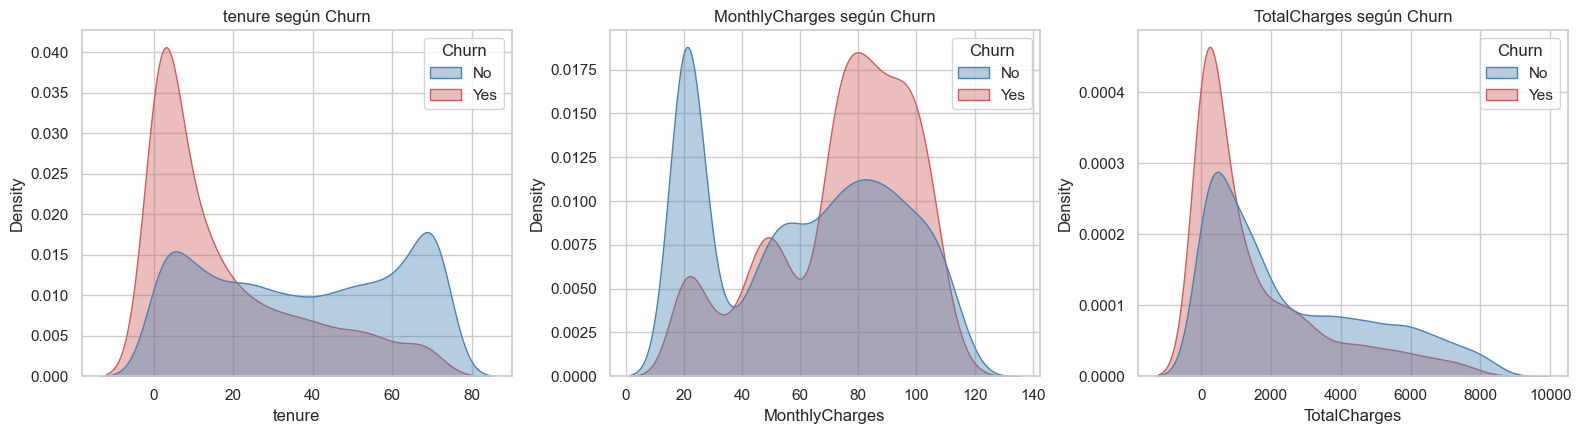

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=df, x=col, hue="Churn", hue_order=["No", "Yes"],
                fill=True, common_norm=False, alpha=0.4,
                palette=["steelblue", "indianred"], ax=ax)
    ax.set_title(f"{col} según Churn")
plt.tight_layout()
plt.show()

Quienes cancelan promedian 18,0 meses de antigüedad frente a 37,6 meses
de quienes permanecen, la grafica muestra que `tenure` es la numérica más discriminante. La
densidad muestra una fuerte concentración de cancelaciones en los
primeros meses, patrón típico de fuga temprana.

En el caso de `MonthlyCharges` se invierte el signo, es decir quienes cancelan pagan más por mes
(74,44 contra 61,27). Combinado con la fibra óptica, apunta a que el
riesgo se concentra en clientes de tarifa alta y poca antigüedad por otro lado, `TotalCharges` es menor entre quienes cancelan (1.531,80 contra
2.555,34).

### 3.7 Correlación entre variables numéricas

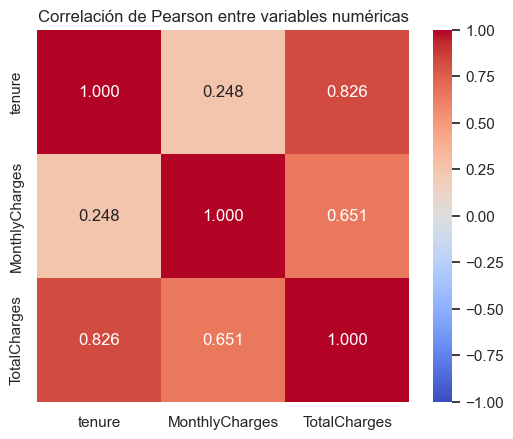

,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.276,0.889
MonthlyCharges,0.276,1.000,0.638
TotalCharges,0.889,0.638,1.000


In [20]:
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlación de Pearson entre variables numéricas")
plt.tight_layout()
plt.show()

display(df[num_cols].corr(method="spearman").round(3))

Correlación entre TotalCharges y (tenure × MonthlyCharges): 0.9996
Varianza de TotalCharges explicada por el producto: 99.91 %


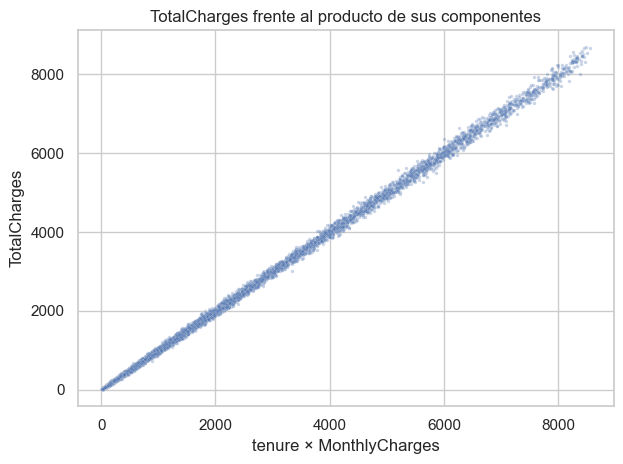

In [21]:
# ¿Es TotalCharges una función de las otras dos?
d = df.dropna(subset=["TotalCharges"])
producto = d["tenure"] * d["MonthlyCharges"]
r = np.corrcoef(d["TotalCharges"], producto)[0, 1]

print(f"Correlación entre TotalCharges y (tenure × MonthlyCharges): {r:.4f}")
print(f"Varianza de TotalCharges explicada por el producto: {r**2*100:.2f} %")

sns.scatterplot(x=producto, y=d["TotalCharges"], s=6, alpha=0.3)
plt.xlabel("tenure × MonthlyCharges"); plt.ylabel("TotalCharges")
plt.title("TotalCharges frente al producto de sus componentes")
plt.tight_layout(); plt.show()

In [23]:
# Factor de inflación de la varianza
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = d[num_cols].assign(const=1)
vif = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [round(variance_inflation_factor(X_vif.values, i), 2)
            for i in range(X_vif.shape[1])]
})
display(vif[vif["variable"] != "const"])

,variable,VIF
0,tenure,5.84
1,MonthlyCharges,3.23
2,TotalCharges,9.53


La correlación más alta es la de `TotalCharges` con `tenure` (0,826 en
Pearson, 0,889 en Spearman). `TotalCharges` correlaciona también con
`MonthlyCharges` (0,651), mientras que `tenure` y `MonthlyCharges` son
casi independientes entre sí (0,247).

Ese patrón tiene una explicación algebraica, no estadística, ya que
`TotalCharges` es el acumulado facturado, que equivale aproximadamente al
producto de la antigüedad por la tarifa mensual. La correlación entre
`TotalCharges` y `tenure × MonthlyCharges` es 0,9996: el producto explica
el 99,91 % de su varianza. `TotalCharges` no es una tercera variable
informativa, es una función determinística de las otras dos.

El factor de inflación de la varianza lo confirma: 9,53 para
`TotalCharges`, frente a 5,84 en `tenure` y 3,23 en `MonthlyCharges`. El
umbral habitual de alerta se sitúa entre 5 y 10, de modo que
`TotalCharges` se encuentra en el límite superior.

Se examinaron tres alternativas. **Eliminar TotalCharges** sería lo más limpio
desde la colinealidad, pero descarta la información residual sobre
cambios de plan y resulta innecesario en modelos de árbol, insensibles a
la colinealidad, **transformarla** en el residuo respecto del producto
`tenure × MonthlyCharges` aislaría esa información residual, pero añade
complejidad desproporcionada frente al 0,09 % de varianza en juego, finalmente
**conservarla** es la decisión adoptada, condicionada al modelo.

## 4. Preparación de los datos

La preparación se divide en dos bloques según un criterio único: si la
transformación estima algún parámetro a partir de la distribución de los
datos.

**4.1 Transformaciones deterministas.** No aprenden nada del conjunto: el
resultado para cada observación depende únicamente de esa observación.
Se aplican sobre el conjunto completo antes de la partición, sin riesgo
de fuga, porque no existe ningún parámetro estimado que pueda filtrarse
del conjunto de prueba.

**4.2 Transformaciones que estiman parámetros.** Imputación estadística,
escalamiento y codificación de categorías requieren aprender de la
distribución. Se declaran aquí pero **no se ajustan**: se encapsulan en
un `Pipeline` que se ajusta después de la partición, únicamente sobre el
conjunto de entrenamiento.

Para este caso del dataset, nos enfocamos en:

### 4.1 Transformaciones deterministas

#### 4.1.1 Eliminación del identificador

In [24]:
df_prep = df.copy()
df_prep = df_prep.drop(columns=["customerID"])
print("Columnas tras eliminar el identificador:", df_prep.shape[1])

Columnas tras eliminar el identificador: 20


`customerID` toma un valor distinto en cada uno de los 7.043 registros . Un identificador único no contiene información
generalizable.

#### 4.1.2 Codificación de la variable objetivo

In [25]:
df_prep["Churn"] = (df_prep["Churn"] == "Yes").astype(int)

print(df_prep["Churn"].value_counts().to_dict())
print(f"Proporción de la clase positiva: {df_prep['Churn'].mean()*100:.2f} %")

{0: 5174, 1: 1869}
Proporción de la clase positiva: 26.54 %


### 4.2 Imputación de valores faltantes

In [26]:
print("Faltantes antes:", df_prep["TotalCharges"].isna().sum())

df_prep["TotalCharges"] = df_prep["TotalCharges"].fillna(0)

print("Faltantes después:", df_prep["TotalCharges"].isna().sum())
display(df_prep.loc[df_prep["tenure"] == 0,
                    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Faltantes antes: 11
Faltantes después: 0


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,0.0,0
753,0,20.25,0.0,0
936,0,80.85,0.0,0
1082,0,25.75,0.0,0
1340,0,56.05,0.0,0
3331,0,19.85,0.0,0
3826,0,25.35,0.0,0
4380,0,20.00,0.0,0
5218,0,19.70,0.0,0
6670,0,73.35,0.0,0


Los 11 valores faltantes de `TotalCharges` (0,156 %) se imputan con el
valor 0.

La decisión se basa en el significado de la variable, no en un criterio
estadístico. Todos los registros afectados corresponden a clientes con
`tenure = 0`, es decir, recién suscritos que aún no han recibido su
primera factura. Su facturación acumulada no es un dato
perdido sino uno que todavía no existe, y el valor coherente con esa
situación es cero.

Se descartaron dos alternativas. Eliminar los registros habría
excluido precisamente al segmento de clientes nuevos, el de mayor
interés para una campaña de retención temprana.
Imputar por la mediana (1.397,48) habría asignado a un cliente de
cero meses la facturación acumulada de uno de veintinueve.



## 5. Separación de entrenamiento y prueba

### 5.1 Separación de predictoras y variable objetivo

In [27]:
X = df_prep.drop(columns=["Churn"])
y = df_prep["Churn"]

print("Matriz de predictoras X:", X.shape)
print("Vector objetivo y:", y.shape)
print("\nColumnas de X:", list(X.columns))

Matriz de predictoras X: (7043, 19)
Vector objetivo y: (7043,)

Columnas de X: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


Se separan las 19 predictoras de la variable objetivo. La exclusión
explícita de `Churn` de la matriz `X` constituye la primera verificación
contra la fuga de información, esto garantiza que la variable a predecir no
puede intervenir como predictora de sí misma.

### 5.2 Partición estratificada

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f} %)")
print(f"Prueba:        {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f} %)")
print(f"\nCancelaciones en el conjunto de prueba: {y_test.sum()}")

Entrenamiento: 5,634 registros (80.0 %)
Prueba:        1,409 registros (20.0 %)

Cancelaciones en el conjunto de prueba: 374


In [29]:
comparacion = pd.DataFrame({
    "conjunto_completo": y.value_counts(normalize=True) * 100,
    "entrenamiento": y_train.value_counts(normalize=True) * 100,
    "prueba": y_test.value_counts(normalize=True) * 100
}).round(2)
comparacion.index = ["No cancela (0)", "Cancela (1)"]
display(comparacion)

,conjunto_completo,entrenamiento,prueba
No cancela (0),73.46,73.46,73.46
Cancela (1),26.54,26.54,26.54


Del conjunto de datos el 80 % para entrenamiento (5.634 registros) y 20 % para
prueba (1.409 registros). El metodo de separacion se hace con  muestreo aleatorio estratificado por la variable objetivo,
mediante `train_test_split` con `stratify=y`. La estratificación fuerza a que ambos subconjuntos conserven la proporción 26,5 / 73,5 del
conjunto completo, como confirma la tabla anterior.

Asi mismo,`random_state=RANDOM_STATE` fija la partición: toda
ejecución posterior del notebook obtiene exactamente los mismos
conjuntos, requisito para que los resultados reportados sean
verificables.

### 5.3 Análisis de grupos naturales

La especificación advierte que, cuando existen grupos naturales en los
datos (pacientes, usuarios, vehículos), la partición aleatoria
tradicional puede generar fuga de información.

In [30]:
print("Registros totales:", len(df))
print("customerID únicos:", df["customerID"].nunique())
print("Filas duplicadas:", df.duplicated().sum())
print("¿Un registro por cliente?:", df["customerID"].nunique() == len(df))

Registros totales: 7043
customerID únicos: 7043
Filas duplicadas: 0
¿Un registro por cliente?: True


El conjunto no presenta estructura de grupos que obligue a una partición
agrupada. `customerID` toma 7.043 valores distintos en 7.043 registros:
cada fila corresponde a un cliente diferente y ningún individuo aparece
más de una vez.

Esto descarta el riesgo característico de los datos agrupados.
Tampoco existe estructura temporal que exigiera una partición
cronológica: el conjunto es un corte transversal sin variables de fecha, de modo que no hay orden entre observaciones ni riesgo de
entrenar con información posterior al momento de la predicción.

Consideramos que la partición aleatoria estratificada es apropiada para
este conjunto.

## 6. Prevención de fuga de información

Se revisan a continuación los mecanismos de fuga aplicables a este
conjunto y las acciones adoptadas frente a cada uno.
La variable objetivo no interviene como predictora. `Churn` se
excluyó explícitamente de la matriz `X` al construirla.

El conjunto de prueba no participa en el entrenamiento. La partición
se realizó antes de ajustar cualquier componente del modelo.
`X_test` e `y_test` no se emplean en ninguna operación hasta la
evaluación final, y en particular no intervienen en la
selección de hiperparámetros, que se realiza mediante validación cruzada
sobre el conjunto de entrenamiento.

La imputación de `TotalCharges` se aplicó antes de la partición, lo cual no genera fuga porque se realizó con la
constante 0 derivada del significado de la variable, sin estimar ningún
parámetro a partir de la distribución de los datos. Una imputación por
media o mediana sí habría requerido ajustarse dentro del pipeline.

No se emplean variables conocidas solo después del evento. Las 19
predictoras describen el estado contractual, los servicios y la
facturación del cliente en el momento del corte, información disponible
antes de que ocurra una eventual cancelación.

Cada cliente aparece una
sola vez en el conjunto, por lo que ningún individuo puede
figurar simultáneamente en entrenamiento y prueba.

In [31]:
# Verificaciones programáticas
print("1. 'Churn' entre las predictoras:", "Churn" in X.columns)
print("2. Solapamiento de índices train/test:",
      len(set(X_train.index) & set(X_test.index)))
print("3. Suma de tamaños == total:",
      len(X_train) + len(X_test) == len(X))
print("4. Columnas idénticas en ambos conjuntos:",
      list(X_train.columns) == list(X_test.columns))
print("5. Faltantes restantes en entrenamiento:", X_train.isna().sum().sum())
print("6. Faltantes restantes en prueba:", X_test.isna().sum().sum())

1. 'Churn' entre las predictoras: False
2. Solapamiento de índices train/test: 0
3. Suma de tamaños == total: True
4. Columnas idénticas en ambos conjuntos: True
5. Faltantes restantes en entrenamiento: 0
6. Faltantes restantes en prueba: 0
